# Eksperimen Learning Rate + Perbandingan dengan SKLearn
Akan dibahas variasi learning rate untuk FFNN dari scratch, visualisasi kurva loss serta distribusi bobot dan gradien, dan perbandingan hasil prediksi akhir dengan sklearn MLPClassifier.

In [31]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

sys.path.append(str(Path().resolve().parent))

from data_prep import load_and_preprocess_data
from ffnn import FFNN

In [32]:
np.random.seed(42)

data_path = Path.cwd().parent.parent / 'data' / 'global_student_placement_and_salary.csv'

X_train, y_train_raw, X_val, y_val_raw = load_and_preprocess_data(str(data_path))

num_classes = len(np.unique(y_train_raw))
is_binary = num_classes == 2

if is_binary:
    y_train = y_train_raw.reshape(-1, 1).astype(np.float64)
    y_val = y_val_raw.reshape(-1, 1).astype(np.float64)
    output_size = 1
    output_activation = 'sigmoid'
    loss_type = 'binary_crossentropy'
else:
    y_train = np.eye(num_classes)[y_train_raw]
    y_val = np.eye(num_classes)[y_val_raw]
    output_size = num_classes
    output_activation = 'softmax'
    loss_type = 'categorical_crossentropy'

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('num_classes =', num_classes, '| binary =', is_binary)

Train: (8000, 11) (8000, 1)
Val  : (2000, 11) (2000, 1)
num_classes = 2 | binary = True


In [33]:
def predict_labels(model, X, is_binary_model):
    y_pred = model.forward(X)
    if is_binary_model:
        return (y_pred >= 0.5).astype(int).reshape(-1)
    return np.argmax(y_pred, axis=1)

learning_rates = [0.001, 0.01, 0.1]
epochs = 60 # cukup panjang untuk melihat tren, ga terlalu lama
batch_size = 32 # umum digunakan

ffnn_results = {}
ffnn_models = {}

for lr in learning_rates:
    model = FFNN(
        layer_numbers_list=[X_train.shape[1], 16, output_size],
        activation_function_list=['relu', output_activation],
        weight_initial='normal',
    )

    history = model.fit(
        X=X_train,
        y=y_train,
        X_val=X_val,
        y_val=y_val,
        batch_size=batch_size,
        learning_rate=lr,
        epochs=epochs,
        verbose=0,
        loss_type=loss_type,
        reg_type=None,
        lambda_=0.0,
    )

    y_val_pred = predict_labels(model, X_val, is_binary)
    val_accuracy = accuracy_score(y_val_raw, y_val_pred)

    ffnn_results[lr] = {
        'history': history,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_accuracy': val_accuracy,
    }
    ffnn_models[lr] = model

print('Training FFNN selesai untuk semua learning rate.')

Training FFNN selesai untuk semua learning rate.


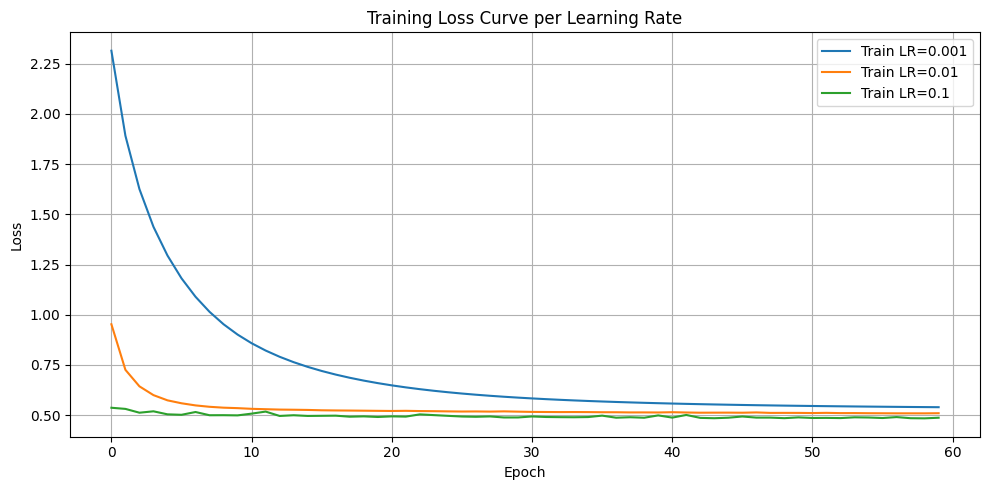

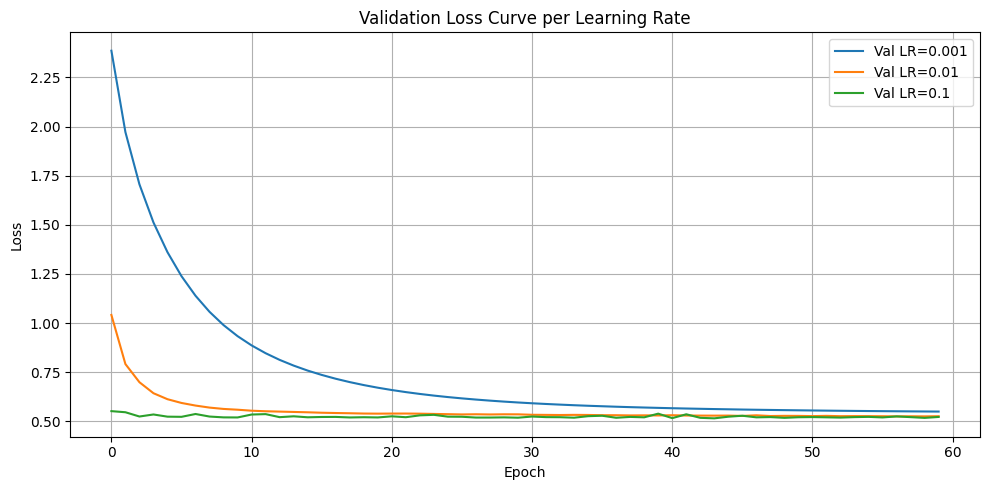

In [34]:
plt.figure(figsize=(10, 5))
for lr in learning_rates:
    plt.plot(ffnn_results[lr]['history']['train_loss'], label=f'Train LR={lr}')

plt.title('Training Loss Curve per Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for lr in learning_rates:
    plt.plot(ffnn_results[lr]['history']['val_loss'], label=f'Val LR={lr}')

plt.title('Validation Loss Curve per Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
summary_rows = []
for lr in learning_rates:
    r = ffnn_results[lr]
    summary_rows.append([lr, r['final_train_loss'], r['final_val_loss'], r['final_val_accuracy']])

print('FFNN final prediction metrics per learning rate')
print('lr | final_train_loss | final_val_loss | final_val_accuracy')
for row in summary_rows:
    print(f'{row[0]:>5} | {row[1]:.6f} | {row[2]:.6f} | {row[3]:.6f}')

best_lr = max(learning_rates, key=lambda x: ffnn_results[x]['final_val_accuracy'])
print('\nBest learning rate by final val accuracy:', best_lr)

FFNN final prediction metrics per learning rate
lr | final_train_loss | final_val_loss | final_val_accuracy
0.001 | 0.539917 | 0.549317 | 0.712000
 0.01 | 0.509980 | 0.525563 | 0.735000
  0.1 | 0.487536 | 0.521933 | 0.732000

Best learning rate by final val accuracy: 0.01



=== Weight and Gradient Distribution for LR=0.001 ===


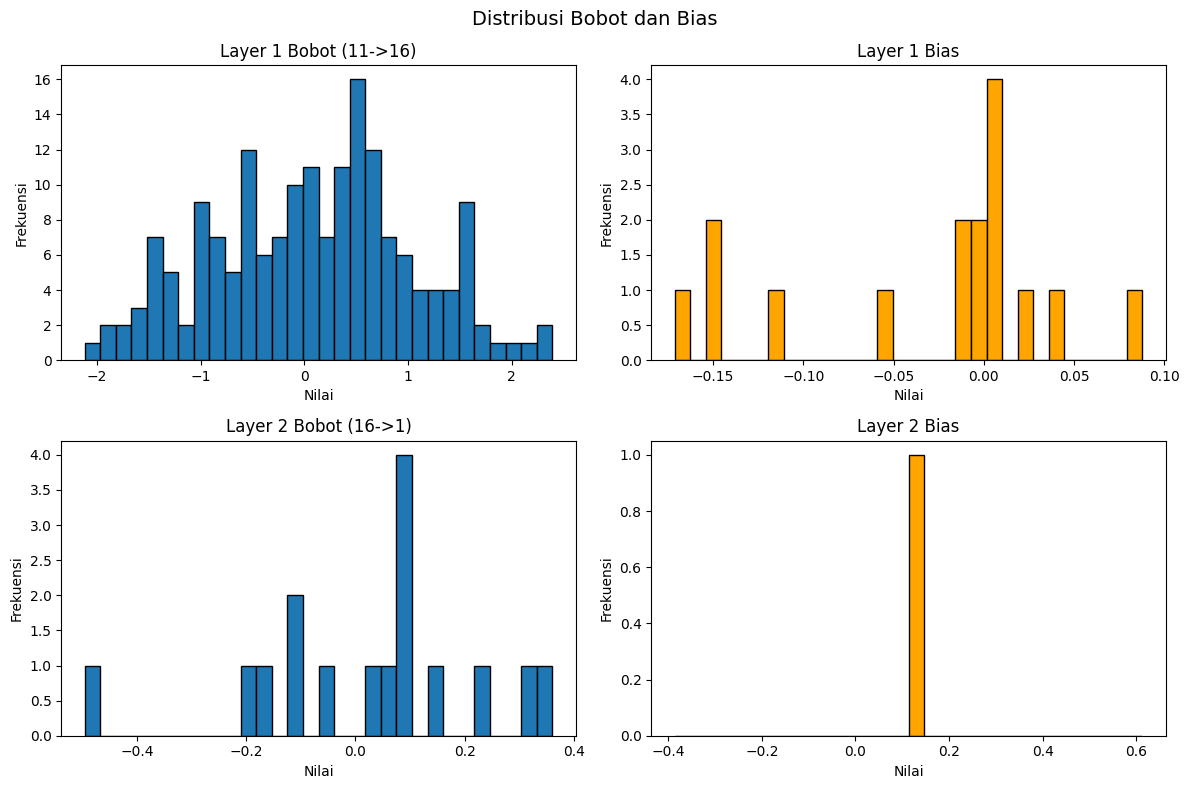

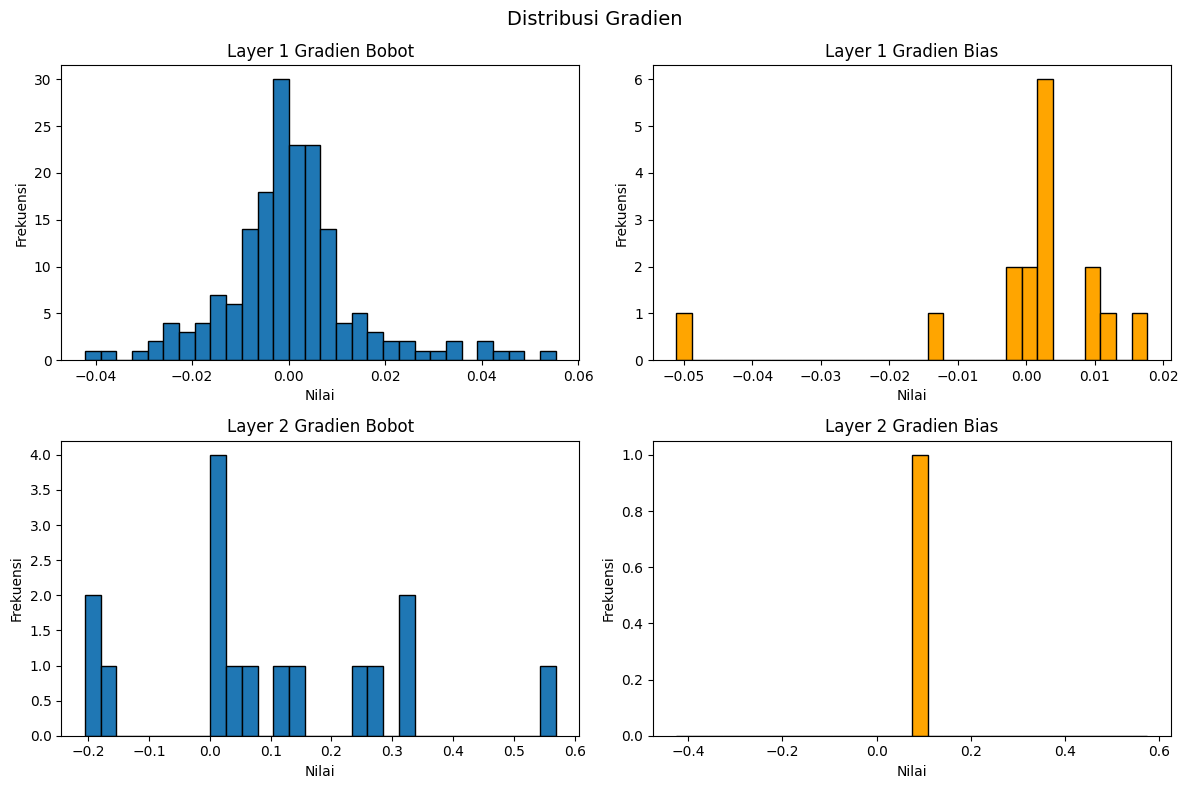


=== Weight and Gradient Distribution for LR=0.01 ===


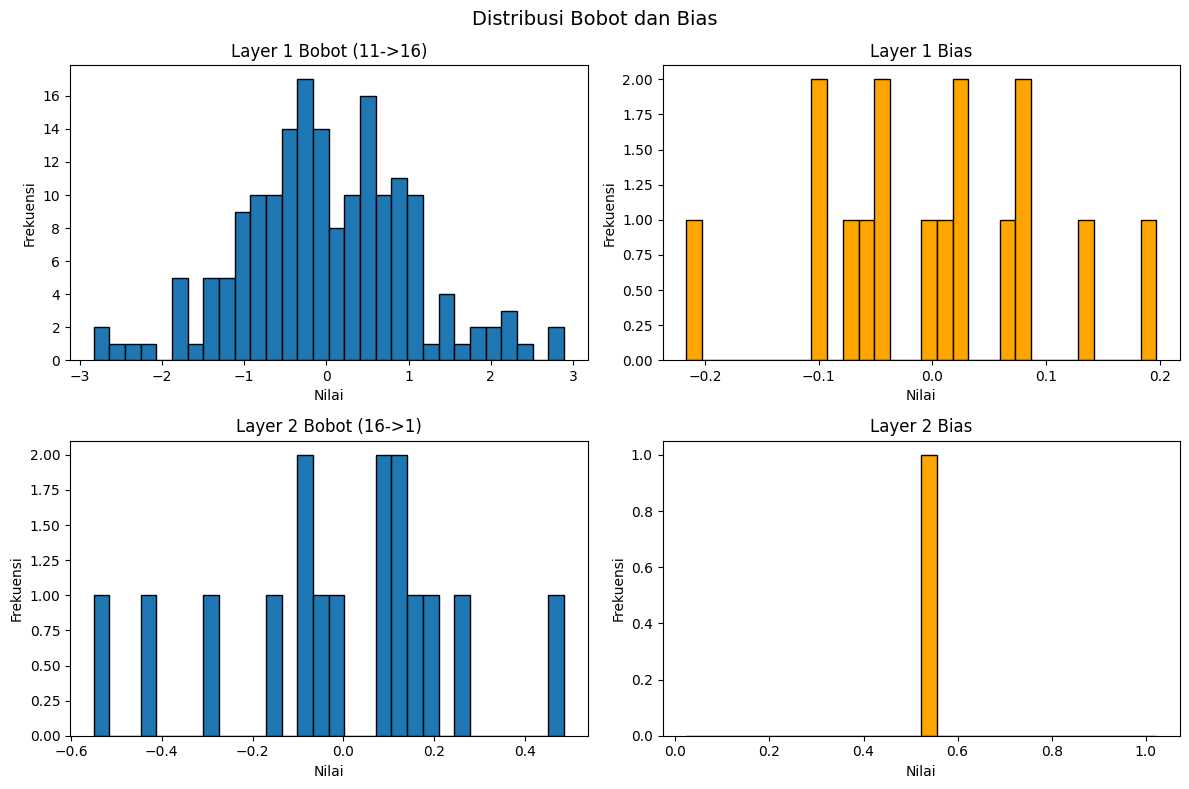

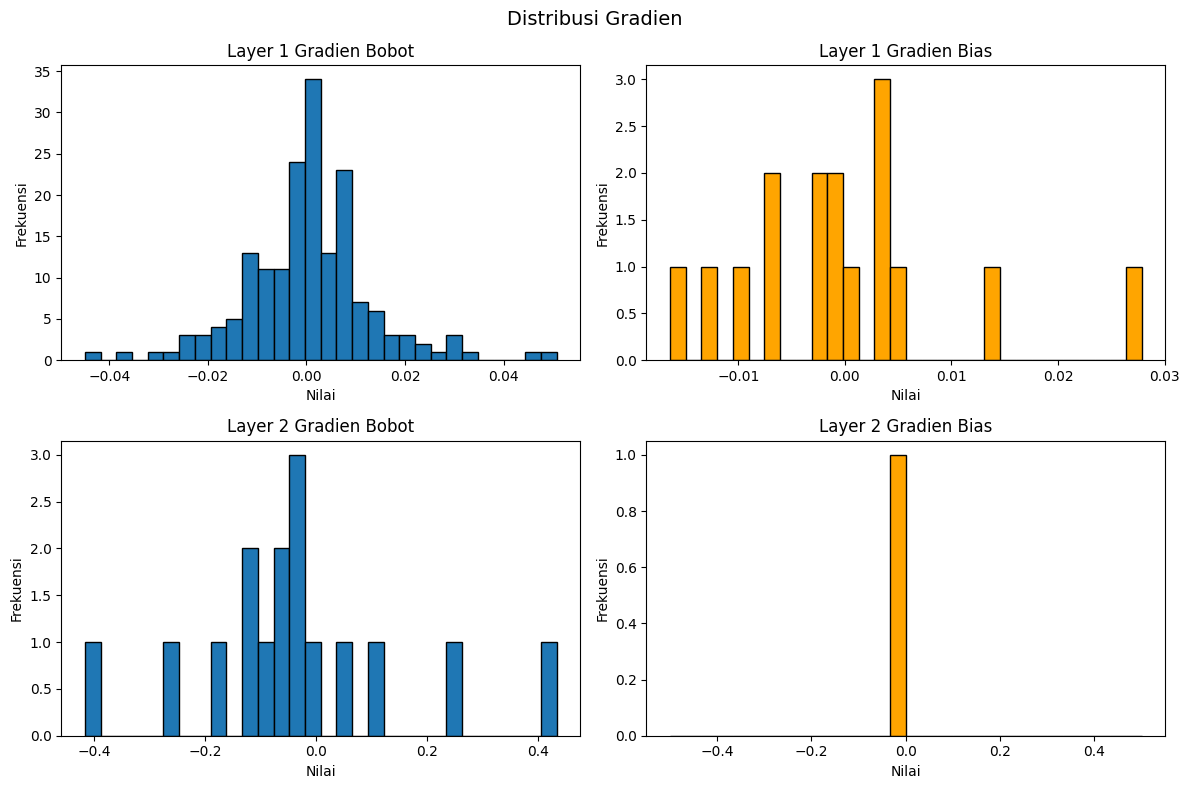


=== Weight and Gradient Distribution for LR=0.1 ===


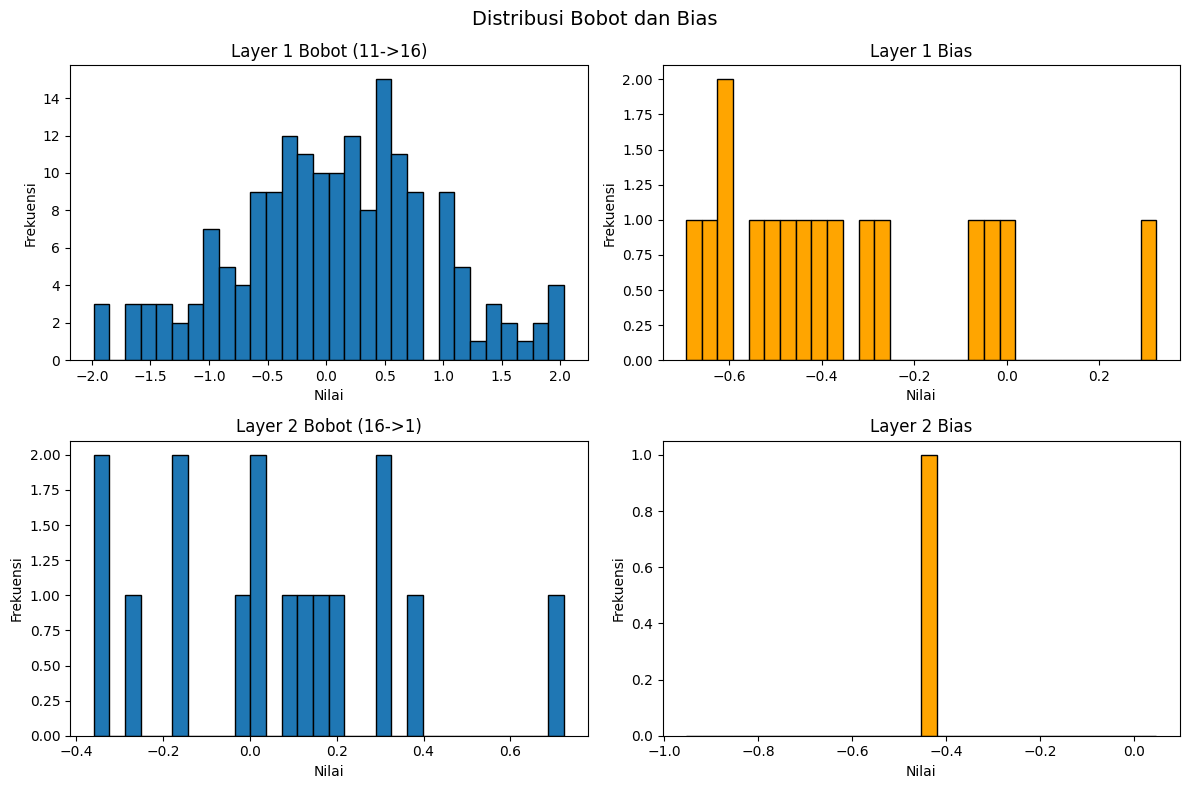

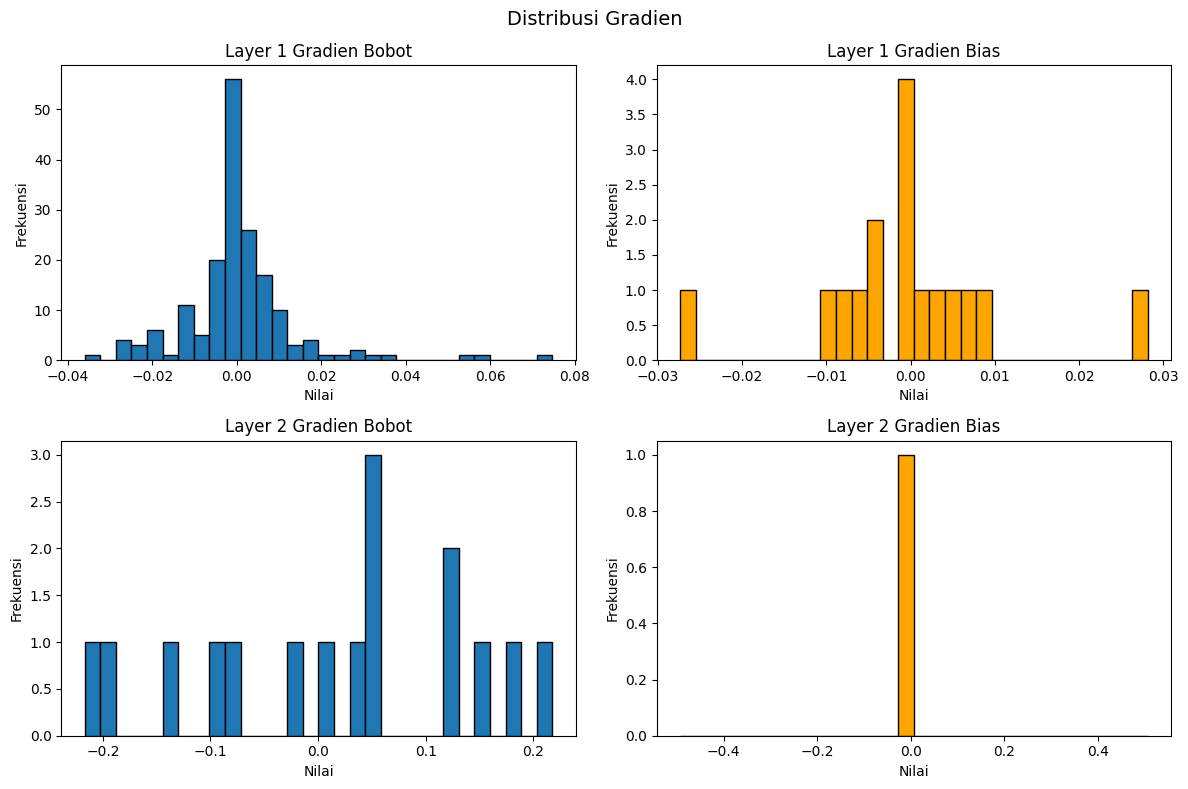

In [36]:
for lr in learning_rates:
    print(f'\n=== Weight and Gradient Distribution for LR={lr} ===')
    model = ffnn_models[lr]
    selected_layers = [0, len(model.weights) - 1] if len(model.weights) > 1 else [0]
    model.plot_weight_distribution(layers=selected_layers)
    model.plot_gradient_distribution(layers=selected_layers)

In [37]:
# sklearn comparison
sk_model = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='sgd',
    learning_rate_init=best_lr,
    batch_size=batch_size,
    max_iter=epochs,
    random_state=42,
    shuffle=True,
)

sk_model.fit(X_train, y_train_raw)
sk_val_pred = sk_model.predict(X_val)
sk_val_acc = accuracy_score(y_val_raw, sk_val_pred)

ffnn_best_acc = ffnn_results[best_lr]['final_val_accuracy']

print('Final prediction comparison (FFNN vs sklearn)')
print(f'FFNN (best LR={best_lr}) val_accuracy   : {ffnn_best_acc:.6f}')
print(f'sklearn MLPClassifier val_accuracy    : {sk_val_acc:.6f}')
print(f'Accuracy gap (sklearn - FFNN)         : {sk_val_acc - ffnn_best_acc:.6f}')

Final prediction comparison (FFNN vs sklearn)
FFNN (best LR=0.01) val_accuracy   : 0.735000
sklearn MLPClassifier val_accuracy    : 0.738500
Accuracy gap (sklearn - FFNN)         : 0.003500


/Users/rafiffarras/SEMESTER_6/ML/Tubes1/clone/trizzzcuit-MachineLearning-FFNN/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


## Save Best Model


In [38]:
project_root = Path.cwd().parent.parent
saved_model_path = project_root / 'saved_model' / 'ffnn_model.npz'

best_model = ffnn_models[best_lr]
saved_model_path.parent.mkdir(parents=True, exist_ok=True)
best_model.save(str(saved_model_path))

notebook_pred = predict_labels(best_model, X_val, is_binary)
notebook_saved_model_acc = accuracy_score(y_val_raw, notebook_pred)

print('Best model berhasil disimpan dari notebook.')
print(f'Path model: {saved_model_path}')
print(f'Akurasi model yang disimpan (di notebook): {notebook_saved_model_acc:.6f}')

Best model berhasil disimpan dari notebook.
Path model: /Users/rafiffarras/SEMESTER_6/ML/Tubes1/clone/trizzzcuit-MachineLearning-FFNN/saved_model/ffnn_model.npz
Akurasi model yang disimpan (di notebook): 0.735000
